## 1. Objectives
- Explore the animal image dataset.
- Prepare images for CNN.
- Split data into training, validation, and testing sets.
- Build a simple CNN from scratch.
- Train and evaluate the model.
- Analyze predictions using standard classification metrics.

## 2. Import Libraries

In [4]:
import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 3. Download Dataset

The Kaggle dataset is downloaded directly. In a cloud environment, make sure Kaggle API access is configured first.

In [5]:
!pip -q install kaggle
!mkdir -p ~/.kaggle

# Upload kaggle.json to /content before running this cell if required.
if os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d miadul/animal-image-classification-5-species -p /content/animal_dataset --unzip
print('Dataset downloaded.')

Dataset URL: https://www.kaggle.com/datasets/miadul/animal-image-classification-5-species
License(s): apache-2.0
100% 5.33M/5.33M [00:00<00:00, 70.0MB/s]

Dataset downloaded.


## 4. Locate Dataset and Classes

In [6]:
BASE_DIR = Path('/content/animal_dataset')
EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}


def count_images(folder):
    return sum(1 for p in Path(folder).rglob('*') if p.is_file() and p.suffix.lower() in EXTS)

# The downloaded Kaggle dataset already contains train/test folders.
# We must NOT select the test folder as the main dataset.
DATASET_ROOT = BASE_DIR / 'animals_dataset'

if not DATASET_ROOT.exists():
    possible = [p for p in BASE_DIR.rglob('*') if p.is_dir() and (p / 'train').is_dir() and (p / 'test').is_dir()]
    if possible:
        DATASET_ROOT = possible[0]

TRAIN_DIR = DATASET_ROOT / 'train'
TEST_DIR = DATASET_ROOT / 'test'
VAL_DIR = DATASET_ROOT / 'validation'

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError('Could not find the original train and test folders in the downloaded dataset.')

print('Dataset root:', DATASET_ROOT)
print('Train folder:', TRAIN_DIR)
print('Test folder:', TEST_DIR)
print('Validation folder exists:', VAL_DIR.exists())

class_folders = sorted([p for p in TRAIN_DIR.iterdir() if p.is_dir() and count_images(p) > 0])
class_names = [p.name for p in class_folders]

print('Classes:', class_names)
print('Number of classes:', len(class_names))
print('Train images:', count_images(TRAIN_DIR))
print('Test images:', count_images(TEST_DIR))
if VAL_DIR.exists():
    print('Validation images:', count_images(VAL_DIR))


Dataset root: /content/animal_dataset/animals_dataset
Train folder: /content/animal_dataset/animals_dataset/train
Test folder: /content/animal_dataset/animals_dataset/test
Validation folder exists: True
Classes: ['cat', 'cow', 'deep', 'dog', 'lion']
Number of classes: 5
Train images: 464
Test images: 82
Validation images: 83


## 5. Dataset Exploration

,Animal Class,Training Images
0,cat,91
1,cow,86
2,deep,87
3,dog,111
4,lion,89


Total training images: 464


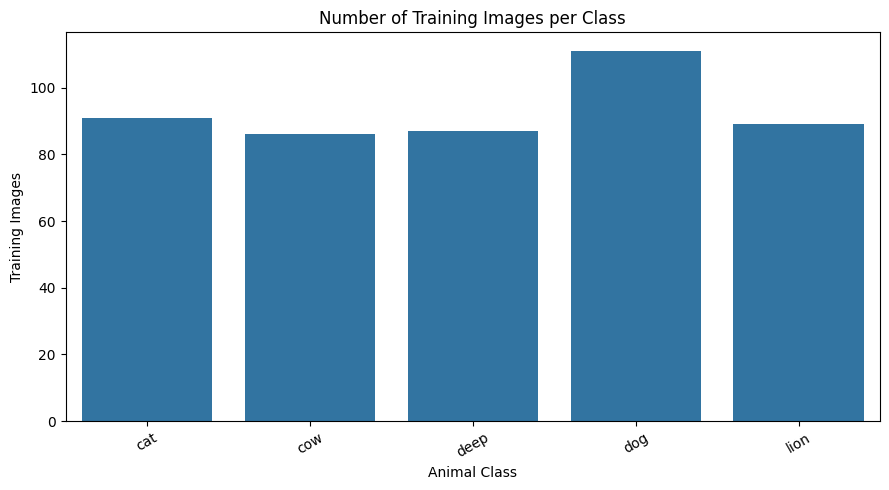

In [7]:
counts = {p.name: count_images(p) for p in class_folders}
df = pd.DataFrame({'Animal Class': list(counts), 'Training Images': list(counts.values())})
display(df)
print('Total training images:', df['Training Images'].sum())

plt.figure(figsize=(9,5))
sns.barplot(data=df, x='Animal Class', y='Training Images')
plt.title('Number of Training Images per Class')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 6. Sample Images

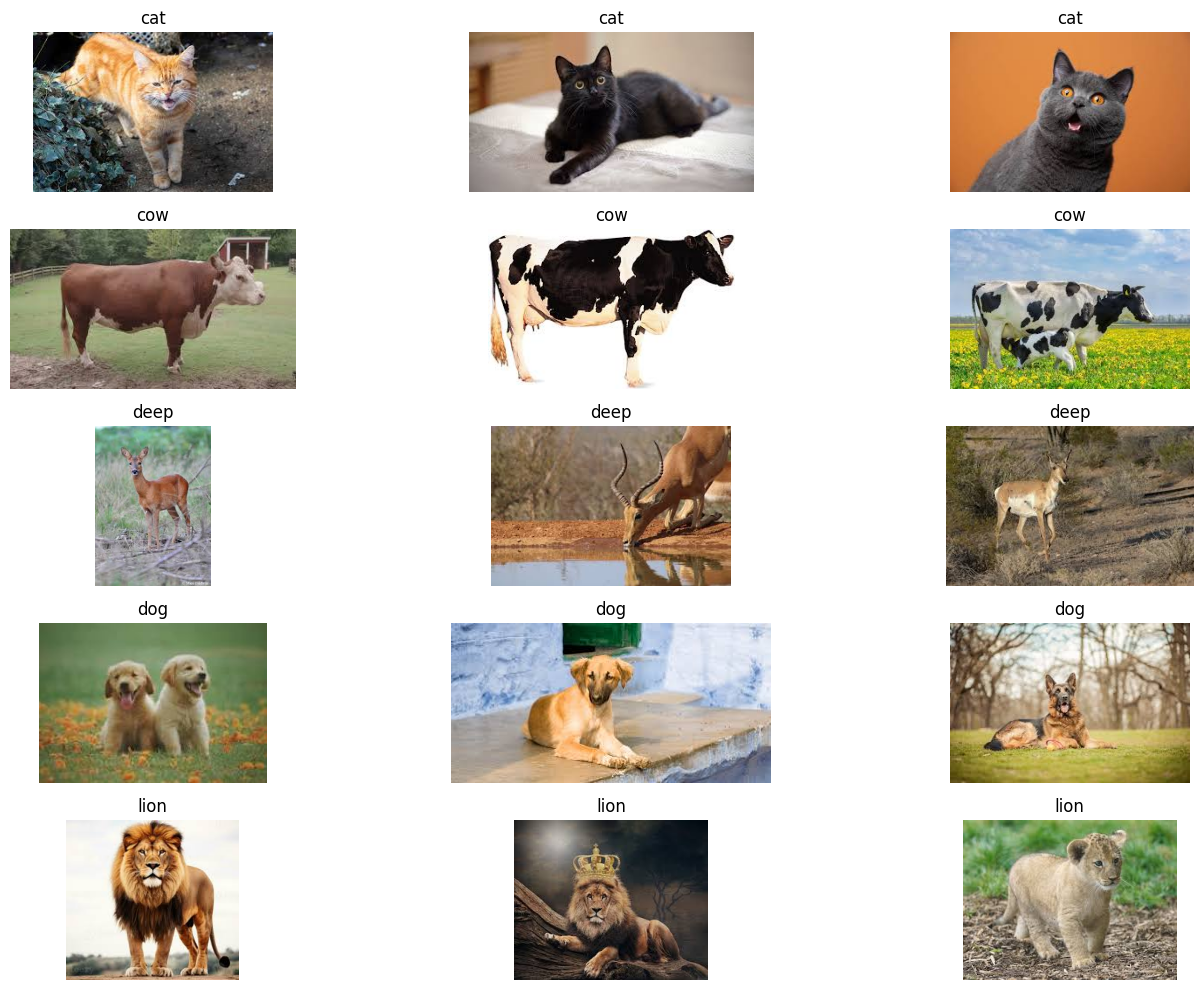

In [8]:
random.seed(42)
plt.figure(figsize=(15,10))
plot_no = 1
for folder in class_folders:
    files = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in EXTS]
    for f in random.sample(files, min(3, len(files))):
        plt.subplot(len(class_folders), 3, plot_no)
        plt.imshow(plt.imread(f))
        plt.title(folder.name)
        plt.axis('off')
        plot_no += 1
plt.tight_layout()
plt.show()


## 7. Train / Validation / Test Split

The Kaggle dataset already provides a separate training and test folder. The original test set is kept untouched. If a validation folder is not provided, 20% of the training data is used for validation.


In [9]:

# We keep the original Kaggle test set untouched.
# Validation is taken from the training folder only when needed.

if VAL_DIR.exists():
    print('Using the validation folder provided by the dataset.')
    print('Train images:', count_images(TRAIN_DIR))
    print('Validation images:', count_images(VAL_DIR))
    print('Test images:', count_images(TEST_DIR))
else:
    print('No separate validation folder found.')
    print('A 20% validation split will be created from TRAIN data only.')
    print('The original TEST data will remain completely unseen until evaluation.')


Using the validation folder provided by the dataset.
Train images: 464
Validation images: 83
Test images: 82


## 8. Image Preprocessing and Augmentation

Images are resized to 128×128 and normalized to 0–1. Simple augmentation is applied only to training images.

In [10]:
IMG_SIZE = (128,128)
BATCH_SIZE = 32

if VAL_DIR.exists():
    train_gen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        zoom_range=0.10
    )
    valid_gen = ImageDataGenerator(rescale=1./255)

    train_data = train_gen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True, seed=42
    )
    val_data = valid_gen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False
    )
else:
    train_gen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        zoom_range=0.10,
        validation_split=0.20
    )
    valid_gen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.20
    )

    train_data = train_gen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training', shuffle=True, seed=42
    )
    val_data = valid_gen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation', shuffle=False, seed=42
    )

test_gen = ImageDataGenerator(rescale=1./255)
test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print('Class mapping:', train_data.class_indices)
print('Training samples:', train_data.samples)
print('Validation samples:', val_data.samples)
print('Test samples:', test_data.samples)


Found 464 images belonging to 5 classes.
Found 83 images belonging to 5 classes.
Found 82 images belonging to 5 classes.
Class mapping: {'cat': 0, 'cow': 1, 'deep': 2, 'dog': 3, 'lion': 4}
Training samples: 464
Validation samples: 83
Test samples: 82


## 9. Build Basic CNN

In [11]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,269 (6.48 MB)

 Trainable params: 1,699,269 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Compile Model

In [12]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
checkpoint=tf.keras.callbacks.ModelCheckpoint('/content/best_animal_cnn.keras',monitor='val_loss',save_best_only=True)

## 11. Train CNN

In [13]:
history=model.fit(train_data,validation_data=val_data,epochs=15,callbacks=[early_stop,checkpoint])

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 574ms/step - accuracy: 0.1832 - loss: 1.6547 - val_accuracy: 0.2048 - val_loss: 1.6083
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.2263 - loss: 1.6046 - val_accuracy: 0.2048 - val_loss: 1.6084
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.2629 - loss: 1.5927 - val_accuracy: 0.3253 - val_loss: 1.5835
Epoch 4/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.2629 - loss: 1.5657 - val_accuracy: 0.2410 - val_loss: 1.5448
Epoch 5/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.3276 - loss: 1.5146 - val_accuracy: 0.4096 - val_loss: 1.4347
Epoch 6/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.3319 - loss: 1.5392 - val_accuracy: 0.4217 - val_loss: 1.4759
Epoch 7/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.3448 - loss: 1.4838 - val_accuracy: 0.4578 - val_loss: 1.4344
Epoch 8/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.4224 - loss: 1.4115 - val_accuracy: 0

## 12. Accuracy and Loss Graphs

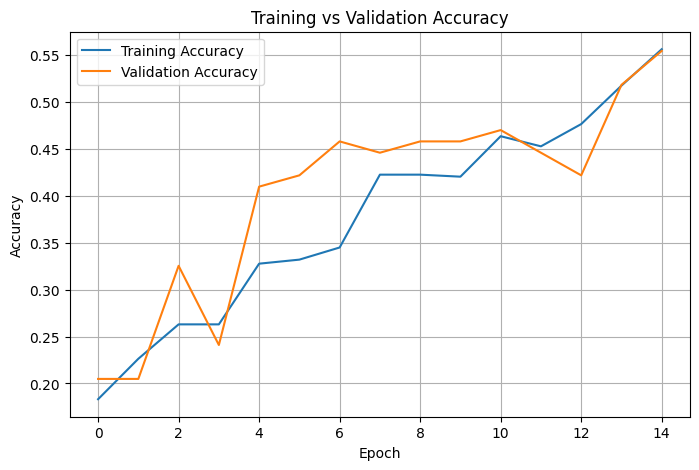

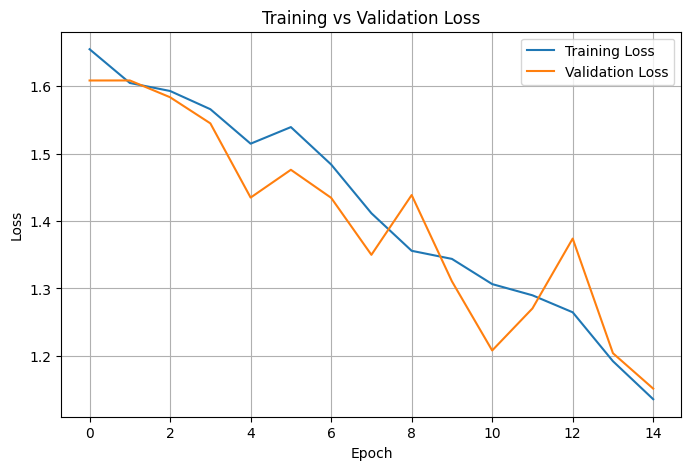

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training vs Validation Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training vs Validation Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(); plt.show()

## 13. Test Evaluation

In [15]:
test_data.reset()
test_loss,test_accuracy=model.evaluate(test_data,verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy*100:.2f}%')

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step - accuracy: 0.5854 - loss: 1.2018
Test Loss: 1.2018
Test Accuracy: 58.54%


## 14. Predictions and Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step


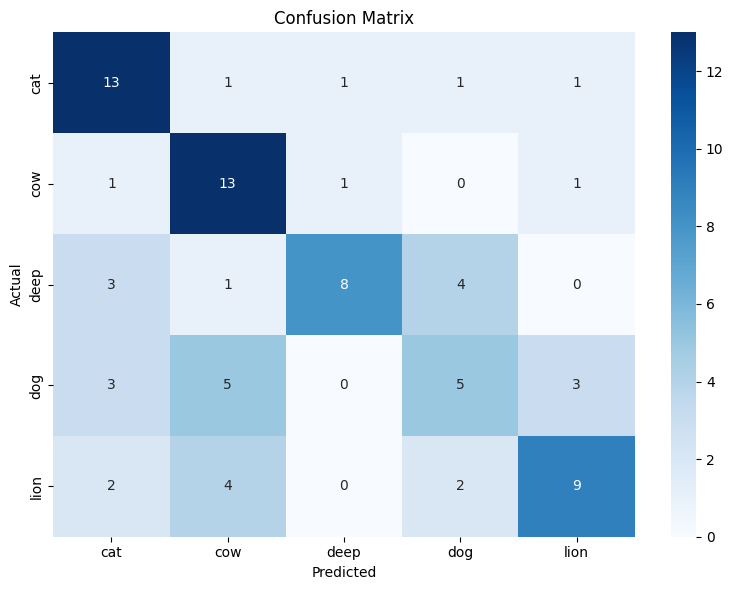

In [16]:
test_data.reset()
probs=model.predict(test_data)
y_pred=np.argmax(probs,axis=1)
y_true=test_data.classes
idx_to_class={v:k for k,v in test_data.class_indices.items()}
labels=[idx_to_class[i] for i in range(num_classes)]

cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.tight_layout(); plt.show()

## 15. Classification Report

In [17]:
print(classification_report(y_true,y_pred,target_names=labels,digits=4))

              precision    recall  f1-score   support

         cat     0.5909    0.7647    0.6667        17
         cow     0.5417    0.8125    0.6500        16
        deep     0.8000    0.5000    0.6154        16
         dog     0.4167    0.3125    0.3571        16
        lion     0.6429    0.5294    0.5806        17

    accuracy                         0.5854        82
   macro avg     0.5984    0.5838    0.5740        82
weighted avg     0.5989    0.5854    0.5752        82



## 16. Sample Test Predictions

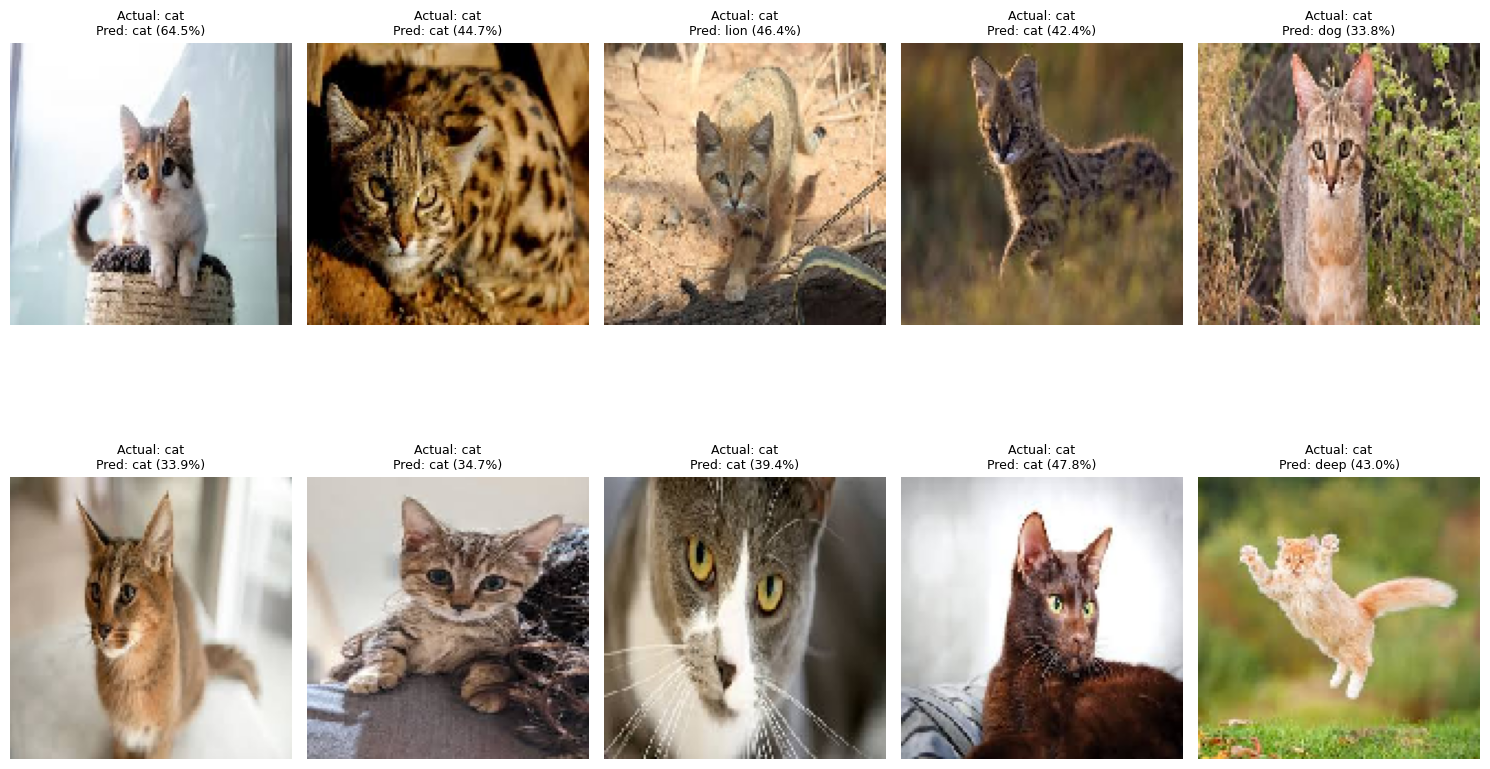

In [18]:
test_data.reset()
images,labels_onehot=next(test_data)
probs=model.predict(images,verbose=0)
preds=np.argmax(probs,axis=1)
actual=np.argmax(labels_onehot,axis=1)

plt.figure(figsize=(15,10))
for i in range(min(10,len(images))):
    plt.subplot(2,5,i+1); plt.imshow(images[i]); plt.axis('off')
    conf=probs[i,preds[i]]*100
    plt.title(f'Actual: {idx_to_class[actual[i]]}\nPred: {idx_to_class[preds[i]]} ({conf:.1f}%)',fontsize=9)
plt.tight_layout(); plt.show()

## 17. Wrong Predictions

Wrong predictions: 34


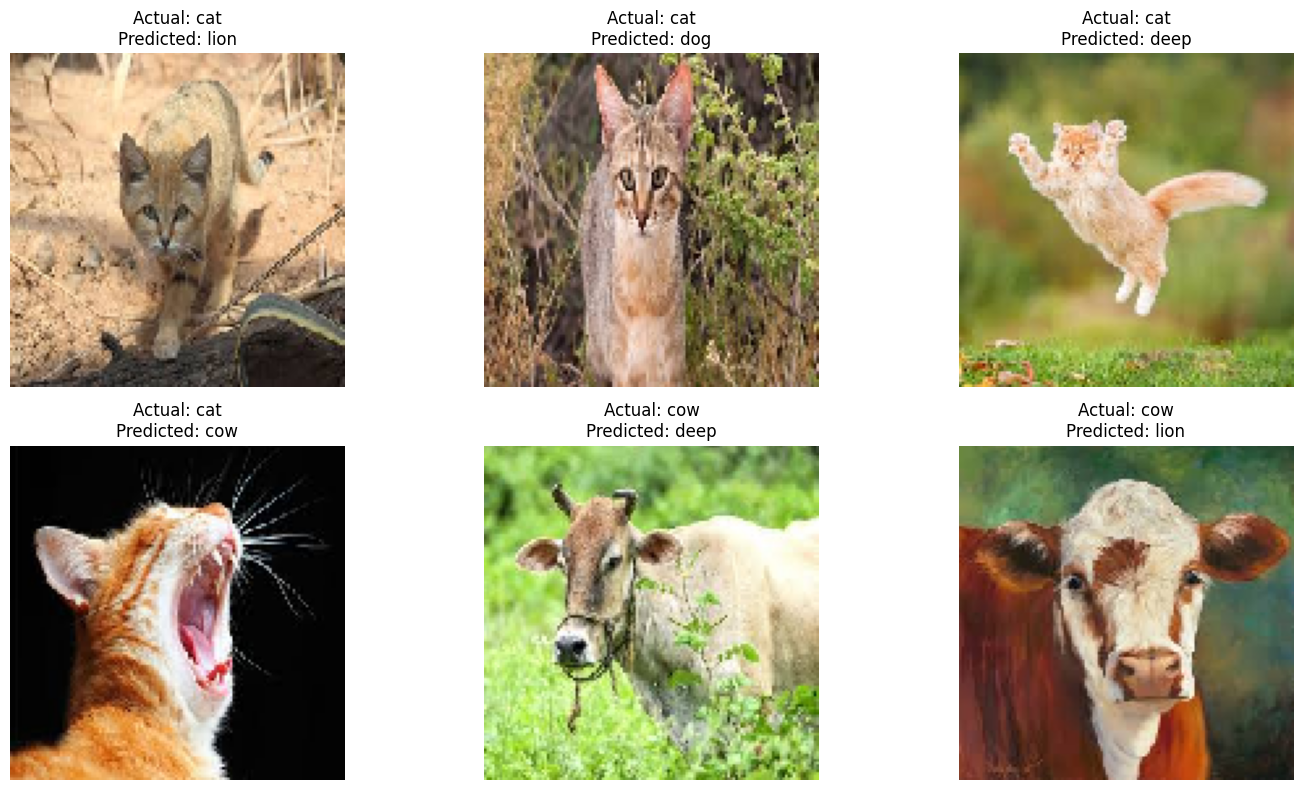

In [19]:
wrong=np.where(y_true!=y_pred)[0]
print('Wrong predictions:',len(wrong))
if len(wrong)>0:
    test_data.reset(); all_x=[]; all_y=[]
    for x,y in test_data:
        all_x.append(x); all_y.append(y)
        if sum(len(a) for a in all_x)>=test_data.samples: break
    all_x=np.concatenate(all_x)[:test_data.samples]
    all_y=np.concatenate(all_y)[:test_data.samples]
    p=model.predict(all_x,batch_size=BATCH_SIZE,verbose=0); pp=np.argmax(p,axis=1); aa=np.argmax(all_y,axis=1)
    plt.figure(figsize=(15,8))
    for j,i in enumerate(np.where(aa!=pp)[0][:6]):
        plt.subplot(2,3,j+1); plt.imshow(all_x[i]); plt.axis('off')
        plt.title(f'Actual: {idx_to_class[aa[i]]}\nPredicted: {idx_to_class[pp[i]]}')
    plt.tight_layout(); plt.show()
else:
    print('No wrong predictions found in the test set.')

## 18. Save Model

In [20]:
model.save('/content/animal_classification_cnn.keras')
print('Saved: /content/animal_classification_cnn.keras')

Saved: /content/animal_classification_cnn.keras
